# Imports

In [507]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

# Loading the Data

In [508]:
data=pd.read_csv('/content/tesla_deliveries_dataset_2015_2025.csv')

In [509]:
df=pd.DataFrame(data)

In [510]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [511]:
df.shape

(2640, 12)

# Understanding the data

In [512]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [513]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [514]:
df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


There are no null values in data

In [515]:
df.duplicated().sum()

np.int64(0)

This says that there is no duplicate information in the data

Seasonality with Month and Estimated_Deliveries

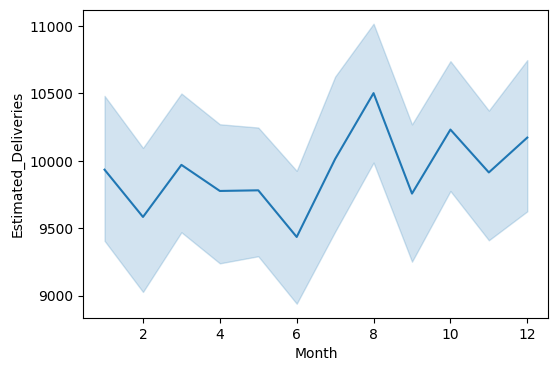

In [516]:
plt.figure(figsize=(6,4))
sns.lineplot(x='Month',y='Estimated_Deliveries', data=df)
plt.show()

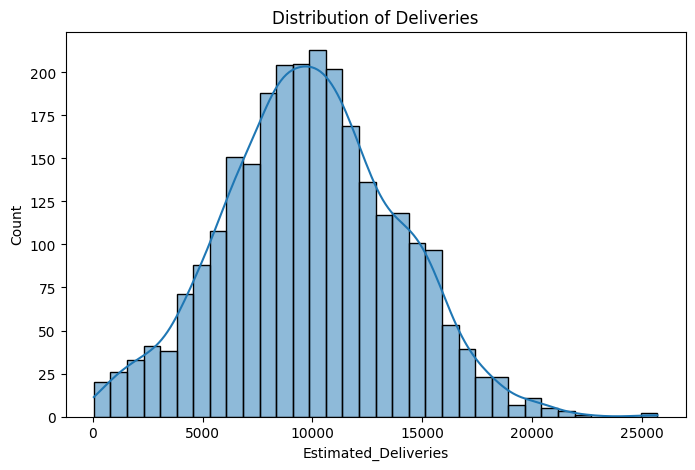

In [517]:
plt.figure(figsize=(8,5))
sns.histplot(df['Estimated_Deliveries'],kde=True)
plt.title('Distribution of Deliveries')
plt.show()

Average number of Deliveries in different regions

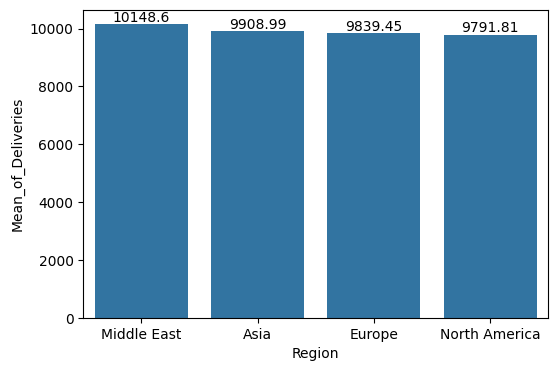

In [518]:
region_deliveries = (df.groupby("Region")["Estimated_Deliveries"].mean().sort_values(ascending=False))
plt.figure(figsize=(6,4))
plt.xlabel('Region')
plt.ylabel('Mean_of_Deliveries')
graph=sns.barplot(x=region_deliveries.index,y=region_deliveries.values)
for c in graph.containers:
  graph.bar_label(c)
plt.show()

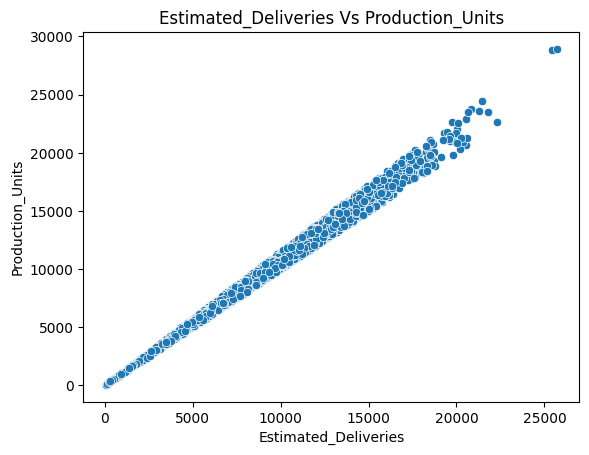

In [519]:
sns.scatterplot(x='Estimated_Deliveries',y='Production_Units',data=df)

plt.title('Estimated_Deliveries Vs Production_Units')
plt.xlabel('Estimated_Deliveries')
plt.ylabel('Production_Units')
plt.show()

The above scatter plot gives information that there is high corelation between those 2 features

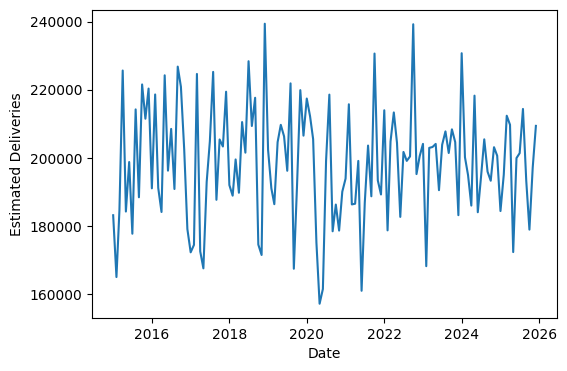

In [520]:
df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' +
    df['Month'].astype(str)
)
monthly_sales = (
    df.groupby("Date")["Estimated_Deliveries"]
      .sum()
)
plt.figure(figsize=(6,4))
plt.plot(monthly_sales.index,monthly_sales.values)
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')
plt.show()

We can say that there is no proper trend over time

In [521]:
df=df.drop('Date',axis=True)

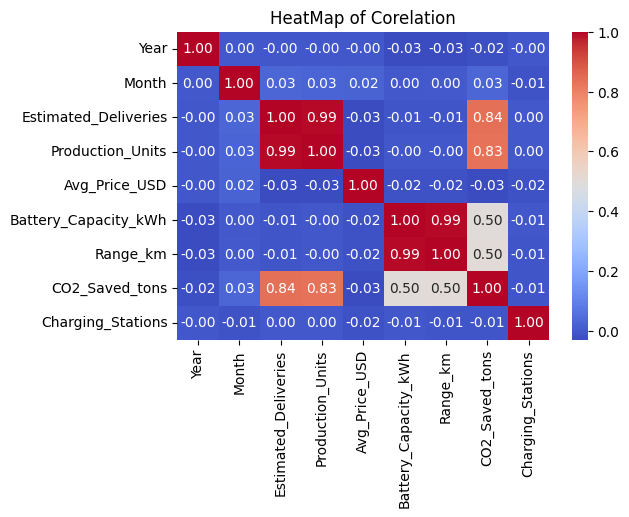

In [522]:
plt.figure(figsize=(6,4))
plt.title('HeatMap of Corelation')
sns.heatmap(df.corr(numeric_only=True),cmap='coolwarm',annot=True,fmt='0.2f')
plt.show()


Through heatmap we can say that Estimated_deliveries and Production_Units are highly Co-related

In [523]:
num_cols=df.select_dtypes(include='number').columns
num_cols=num_cols.drop(['Year','Month','Estimated_Deliveries'])

# Outlier Detection

**Box Plot to check outliers**

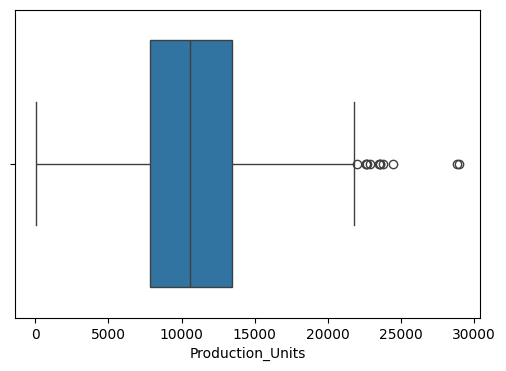

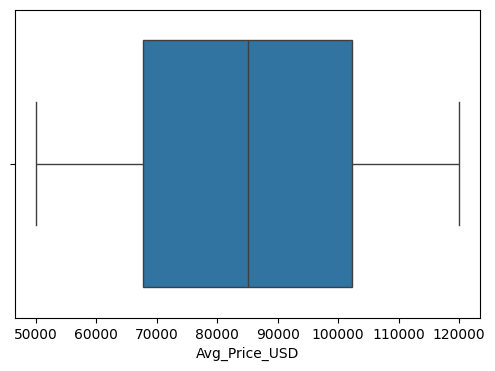

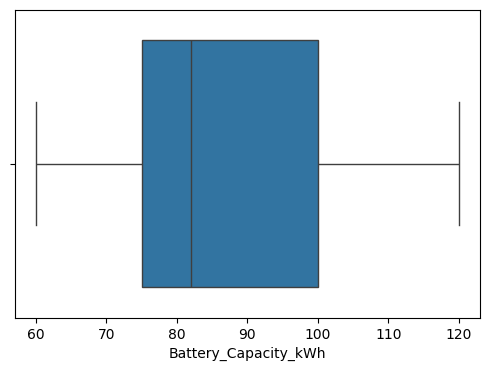

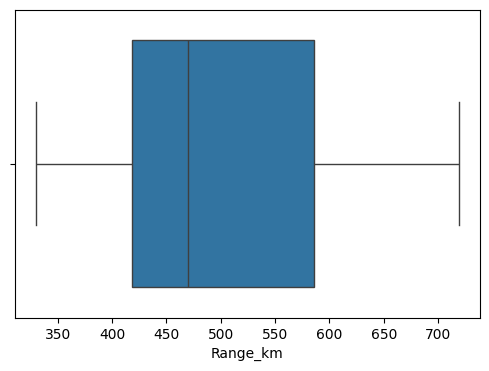

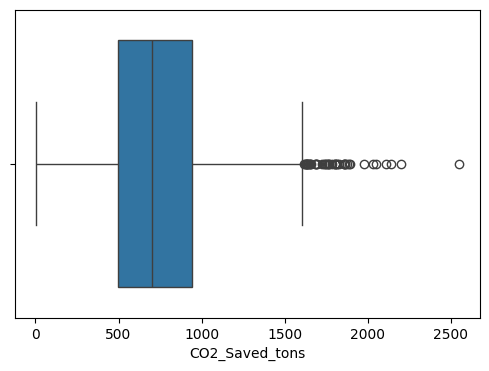

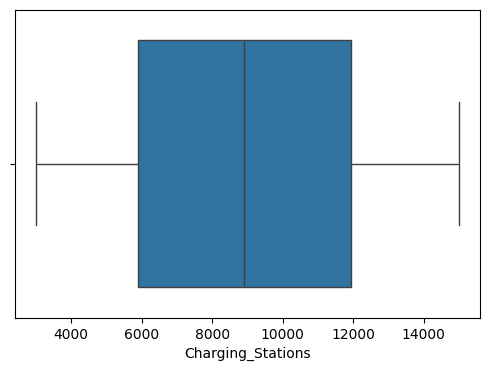

In [524]:
for cols in num_cols:
  plt.figure(figsize=(6,4))
  sns.boxplot(x=df[cols])
  plt.show()

In [525]:
for col in ['Production_Units', 'CO2_Saved_tons']:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)

Clipping the outliers to the ranges

# Encoding Categorical Features

In [526]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   float64
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 247.6+ KB


# Feature Engineering

**Adding Lag Features and Rolling Features**

In [527]:
df['Range_per_KWh'] = (df['Range_km'] /df['Battery_Capacity_kWh'])
df['CO2_Saved_per_Vehicle'] = (df['CO2_Saved_tons'] /(df['Estimated_Deliveries'] + 1)
)
df['Previous_month_deliveries'] = (df['Estimated_Deliveries'].shift(1))
df['Rolling_Estimates'] = (df['Estimated_Deliveries'].rolling(window=3, min_periods=1).mean())
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

In [528]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Range_per_KWh,CO2_Saved_per_Vehicle,Previous_month_deliveries,Rolling_Estimates
1,2015,2,Asia,Model X,3797,4164.0,62205.65,75,438,249.46,Official (Quarter),7640,5.840000,0.065682,17646.0,10721.500000
2,2019,1,North America,Model X,8411,9189.0,117887.32,82,480,605.59,Interpolated (Month),14071,5.853659,0.071991,3797.0,9951.333333
3,2021,2,North America,Model 3,6555,7311.0,89294.91,120,712,700.07,Official (Quarter),9333,5.933333,0.106783,8411.0,6254.333333
4,2016,12,Middle East,Model Y,12374,13537.0,114846.78,120,661,1226.88,Estimated (Region),8722,5.508333,0.099142,6555.0,9113.333333
5,2020,4,Asia,Model X,4656,5043.0,86930.57,82,477,333.14,Official (Quarter),5798,5.817073,0.071535,12374.0,7861.666667


In [529]:
df['Region'].value_counts()

,count
Region,
Asia,660
North America,660
Middle East,660
Europe,659


In [530]:
df['Model'].value_counts()

,count
Model,
Model X,528
Model 3,528
Model Y,528
Cybertruck,528
Model S,527


In [531]:
df['Source_Type'].value_counts()

,count
Source_Type,
Official (Quarter),884
Interpolated (Month),883
Estimated (Region),872


In [532]:
X = df.drop('Estimated_Deliveries', axis=1)
y = df['Estimated_Deliveries']

In [533]:
cat_cols = ['Region','Model','Source_Type']
num_cols = [
col for col in X.columns
    if col not in cat_cols
]

**Pipeline for Data Tranformation for categorical columns does One-Hot Encoding and Scaling for the numerical columns**

In [534]:
preprocessor=ColumnTransformer(transformers=[
    ('num',StandardScaler(),num_cols),
    ('cat',OneHotEncoder(drop='first',handle_unknown='ignore'),cat_cols)
],remainder='passthrough')


In [535]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# Linear Regression

In [536]:
lin_model=Pipeline([('preprocessor',preprocessor),('model',LinearRegression())])
lin_model.fit(X_train,y_train)
y_pred_lin=lin_model.predict(X_test)

**Evaluation Metrics**

In [537]:
print("Mean Absolute Error: ",mean_absolute_error(y_test,y_pred_lin))
print("Mean Squared Error: ",mean_squared_error(y_test,y_pred_lin))
print("Root Mean Squared Error: ",np.sqrt(mean_squared_error(y_test,y_pred_lin)))
print("R2 Score: ",r2_score(y_test,y_pred_lin))

Mean Absolute Error:  318.41122048577597
Mean Squared Error:  217704.11733523442
Root Mean Squared Error:  466.58773808924127
R2 Score:  0.9865145620747287



**Ridge Regression with Hyper Parameter Tuning**




In [538]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])
param_grid = {
    'model__alpha': [0.01, 0.1, 1, 10, 100]
}
grid = GridSearchCV(ridge_pipeline,param_grid,cv=5,scoring='r2')
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
y_pred_ridge = best_model.predict(X_test)

**Evaluation Metrics**

In [539]:
print("Mean Absolute Error: ",mean_absolute_error(y_test,y_pred_ridge))
print("Mean Squared Error: ",mean_squared_error(y_test,y_pred_ridge))
print("Root Mean Squared Error: ",np.sqrt(mean_squared_error(y_test,y_pred_ridge)))
print("R2 Score: ",r2_score(y_test,y_pred_ridge))

Mean Absolute Error:  318.41227046943084
Mean Squared Error:  217707.11945728576
Root Mean Squared Error:  466.5909551816085
R2 Score:  0.9865143761116377


Even the Ridge Regression is giving almost same metrics values as LinearRegression this says that the corelation is not affecting the model.

In [540]:
preprocessor.get_feature_names_out()

array(['num__Year', 'num__Month', 'num__Production_Units',
       'num__Avg_Price_USD', 'num__Battery_Capacity_kWh', 'num__Range_km',
       'num__CO2_Saved_tons', 'num__Charging_Stations',
       'num__Range_per_KWh', 'num__CO2_Saved_per_Vehicle',
       'num__Previous_month_deliveries', 'num__Rolling_Estimates',
       'cat__Region_Europe', 'cat__Region_Middle East',
       'cat__Region_North America', 'cat__Model_Model 3',
       'cat__Model_Model S', 'cat__Model_Model X', 'cat__Model_Model Y',
       'cat__Source_Type_Interpolated (Month)',
       'cat__Source_Type_Official (Quarter)'], dtype=object)

After preprocessing, additional features are created through One-Hot Encoding. Since preprocessing is performed inside the pipeline, these transformed features exist only within the pipeline's transformed output and are not added to the original DataFrame

In [541]:
df.corr(numeric_only=True)['Estimated_Deliveries'].sort_values(ascending=False)

,Estimated_Deliveries
Estimated_Deliveries,1.000000
Production_Units,0.992911
CO2_Saved_tons,0.836262
Rolling_Estimates,0.562927
Month,0.031224
Range_per_KWh,0.013788
Charging_Stations,0.000051
Year,-0.003572
Range_km,-0.007870
Battery_Capacity_kWh,-0.008952


**The Reason for High r2 value because the findings says that the estimated_deliveries mostly is depending on the Production_units so that is the reason for strong or high performance**

# Actual Vs Predicted Plot

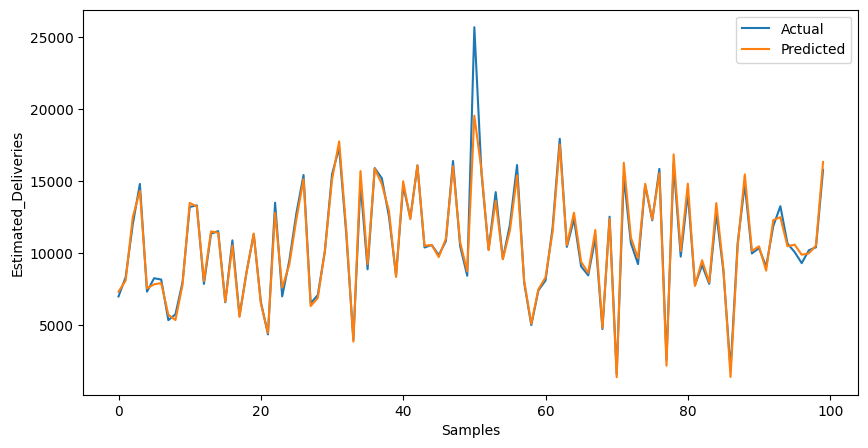

In [542]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100],label='Actual')
plt.plot(y_pred_lin[:100],label='Predicted')
plt.legend()
plt.xlabel('Samples')
plt.ylabel('Estimated_Deliveries')
plt.show()

# Conclusion

**From the data I can conclude that the Estimated_Deliveries is very proportionate to the Production_units so the results majorly depends on that Production_units that is the reason for very high R2_score values. Also we can say that there could be a data leakage beacuse of excellent results but the results are because of high positive co-relation with Production_units**

**Even we can go with more models like RandomForestRegressor, XGBoost Regressor,LightGBM regressor but already the LinearRegression and RidgeRegression are giving Excellent Results and also week2 is all about classical Machine learning I've avoided those heavy models.**